In [1]:
import common_functions

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pandas as pd
import numpy as np
import xarray as xr

In [2]:
dust_df = pd.read_csv("DATA/processed/3_dust_points_vars_2026-05-15.csv")
control_ds = xr.open_dataset("DATA/processed/4_control_grid_2026-05-15.nc")
control_ds_dust_sites = xr.open_dataset("DATA/processed/5_control_grid_dust_sites_2026-05-15.nc")

Create a side-by-side bar chart comparing:
- frequency of soil textures at dust points
- frequency of soil textures in the full soil raster

## Surface categories

In [3]:
soil_cmap, texture_colors, texture_dict = common_functions.get_texture_map_features()
land_cover_dict, land_cover_colors, classes = common_functions.get_land_cover_features()
soil_order_dict, category_colors = common_functions.get_soil_order_features()

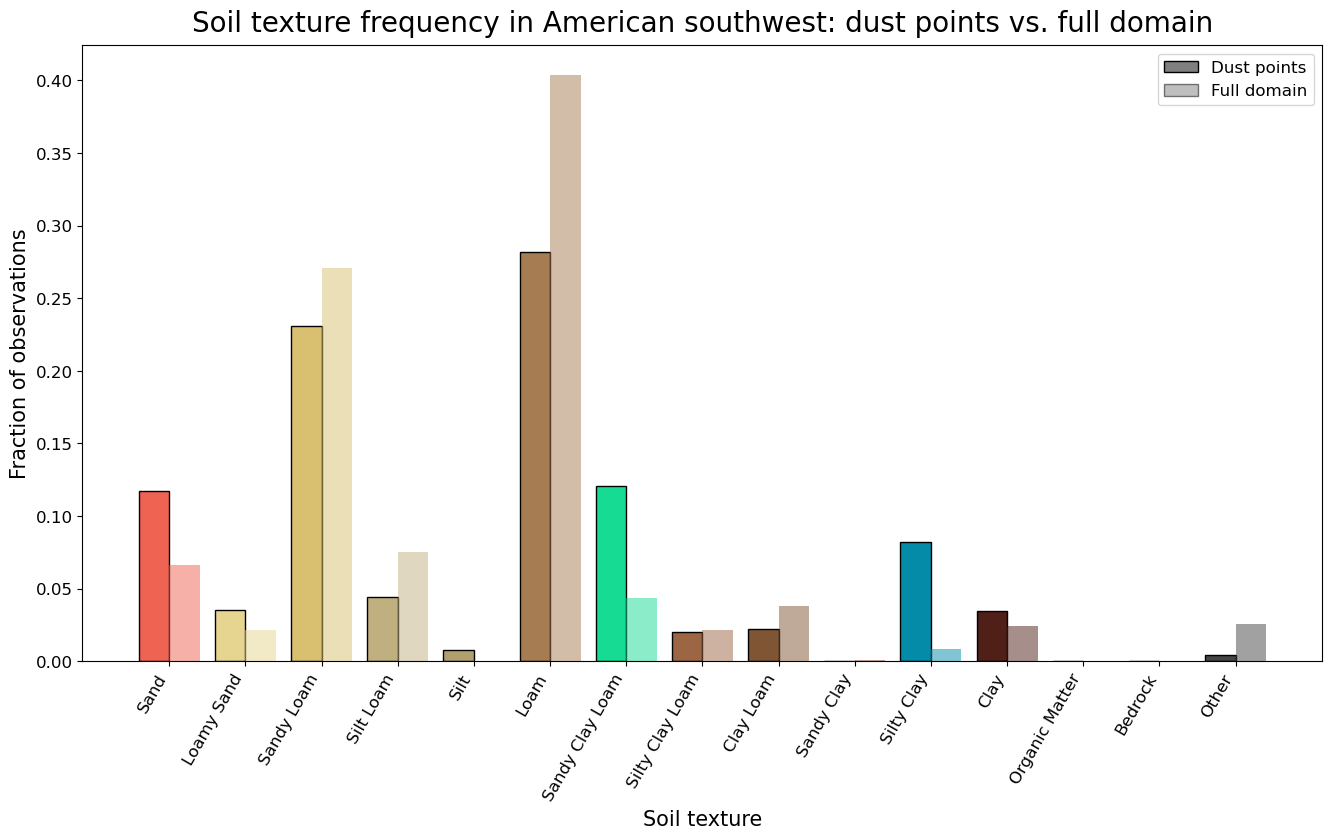

In [4]:
#--- Calculate bins
dust_counts = {k: np.sum(dust_df['texture'] == k) for k in texture_dict.keys()}
dust_total = sum(dust_counts.values())
dust_fraction = {k: v / dust_total for k, v in dust_counts.items()}

non_dust_counts = {k: np.sum(control_ds['soil_texture'] == k) for k in texture_dict.keys()}
non_dust_total = sum(non_dust_counts.values())
non_dust_fraction = {k: v / non_dust_total for k, v in non_dust_counts.items()}

categories = list(texture_dict.keys())
labels = [texture_dict[k] for k in categories]
x = np.arange(len(categories))
width = 0.4

fig, ax = plt.subplots(figsize=(16, 8))

for i, k in enumerate(categories):
    color = texture_colors[i]
    ax.bar(x[i] - width / 2, dust_fraction[k], width, color=color, edgecolor="black", label="Dust points" if i == 0 else "")
    ax.bar(x[i] + width / 2, non_dust_fraction[k], width, color=color, alpha=0.5, label="Full domain" if i == 0 else "")


ax.tick_params(labelsize=12)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=60, ha="right")
ax.set_ylabel("Fraction of observations", fontsize=15)
ax.set_xlabel("Soil texture", fontsize=15)
ax.set_title(f"Soil texture frequency in American southwest: dust points vs. full domain", fontsize=20, pad=10)

legend_elements = [
    Patch(facecolor="gray", edgecolor="black", label="Dust points"),
    Patch(facecolor="gray", edgecolor="black", alpha=0.5, label="Full domain")
]
ax.legend(handles=legend_elements, fontsize=12)

plt.savefig(f"plots/3_texture_1_bar_chart.png",
            dpi=300, bbox_inches='tight')
plt.show()

In [5]:
def add_medians_to_plot(ax_bar, median_dust, median_control):

    ax_bar.axvline(
        median_dust,
        color="tab:orange",
        linestyle="--",
        linewidth=2,
        zorder=0
    )
    ax_bar.text(x=median_dust, 
                y=0.84,
                s=f'Median: {median_dust:.2f}', 
                color="tab:orange",
                alpha=0.8, 
                fontsize=10,
                fontweight='bold',
                rotation=90,
                verticalalignment='center',
                horizontalalignment='right',
                transform=ax_bar.get_xaxis_transform())

    ax_bar.axvline(
        median_control,
        color="tab:blue",
        linestyle="--",
        linewidth=2,
        zorder=0
    )
    
    ax_bar.text(x=median_control, 
                y=0.84,
                s=f'Median: {median_control:.2f}', 
                color="tab:blue",
                alpha=0.8, 
                fontsize=10,
                fontweight='bold',
                rotation=90,
                verticalalignment='center',
                horizontalalignment='right',
                transform=ax_bar.get_xaxis_transform())
    
    return

## Continuous (wind and moisture)

Plotting wind speed bar chart...


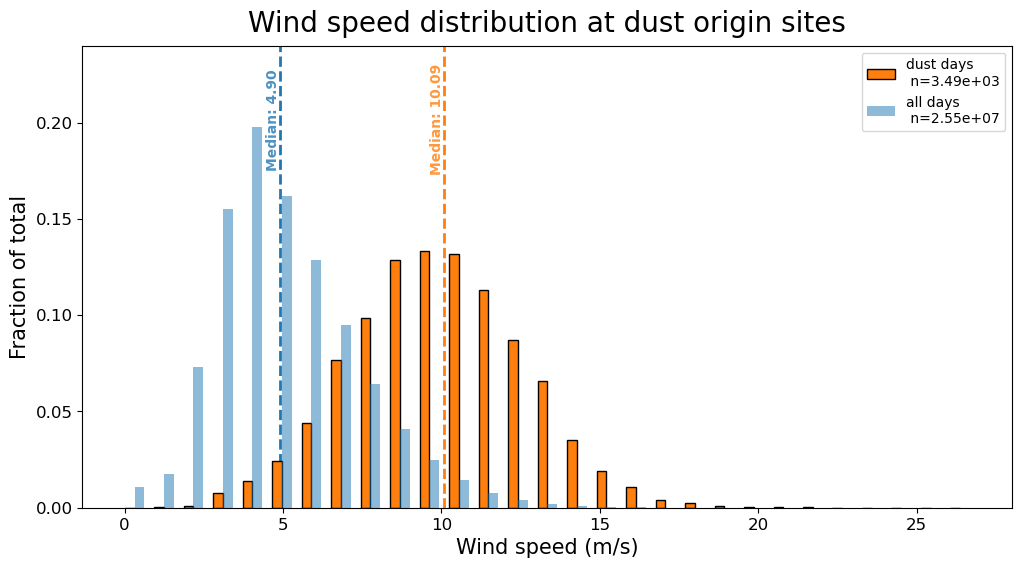

In [6]:
print("Plotting wind speed bar chart...")

#--- Calculate bins
bins = np.linspace(0, 27, 30)
counts_dust_days, _ = np.histogram(dust_df["wind_speed"], bins=bins)
counts_all_days, _ = np.histogram(control_ds_dust_sites["wind_speed"], bins=bins)
width = (bins[1] - bins[0]) / 3
density_dust_days = counts_dust_days / np.sum(counts_dust_days)
density_all_days = counts_all_days / np.sum(counts_all_days)

fig, ax_bar = plt.subplots(figsize=(12, 6))

plt.bar(bins[:-1], density_dust_days, 
        width=width, 
        align='edge', 
        color="tab:orange",
        edgecolor="black",
        linewidth=1,
        label=f"dust days \n n={len(dust_df["wind_speed"]) :.2e}",)
plt.bar(bins[:-1] + width, density_all_days, 
        width=width, 
        align='edge', 
        color="tab:blue",
        label=f"all days \n n={len(dust_df)*len(control_ds_dust_sites["wind_speed"]) :.2e}",
        alpha=0.5)

median_dust = dust_df["wind_speed"].median(skipna=True)
median_control = control_ds_dust_sites["wind_speed"].median(skipna=True)
add_medians_to_plot(ax_bar, median_dust, median_control)

ax_bar.tick_params(labelsize=12)
ax_bar.set_ylim(0,0.24)
ax_bar.set_ylabel("Fraction of total", fontsize=15)
ax_bar.set_xlabel("Wind speed (m/s)", fontsize=15)
ax_bar.set_title("Wind speed distribution at dust origin sites", fontsize=20, pad=10)

ax_bar.legend()
plt.savefig(f"plots/1_wind_speed_bar_chart.png",
            dpi=300, bbox_inches='tight')
plt.show()

Plotting moisture bar chart...


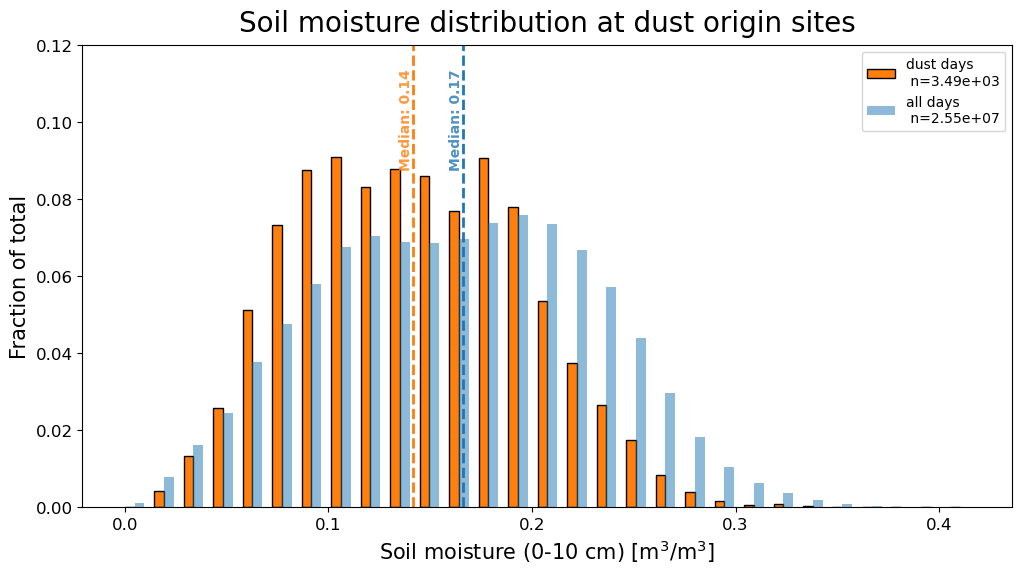

In [7]:
print("Plotting moisture bar chart...")

#--- Calculate bins
bins = np.linspace(0, 0.42, 30)
counts_dust_days, _ = np.histogram(dust_df["moisture"], bins=bins)
counts_all_days, _ = np.histogram(control_ds_dust_sites["SoilMoi00_10cm_tavg"], bins=bins)
width = (bins[1] - bins[0]) / 3
density_dust_days = counts_dust_days / np.sum(counts_dust_days)
density_all_days = counts_all_days / np.sum(counts_all_days)

fig, ax_bar = plt.subplots(figsize=(12, 6))

plt.bar(bins[:-1], density_dust_days, 
        width=width, 
        align='edge', 
        color="tab:orange",
        edgecolor="black",
        linewidth=1,
        label=f"dust days \n n={len(dust_df["moisture"]) :.2e}",)
plt.bar(bins[:-1] + width, density_all_days, 
        width=width, 
        align='edge', 
        color="tab:blue",
        label=f"all days \n n={len(dust_df)*len(control_ds["SoilMoi00_10cm_tavg"]) :.2e}",
        alpha=0.5)

median_dust = dust_df["moisture"].median(skipna=True)
median_control = control_ds_dust_sites["SoilMoi00_10cm_tavg"].median(skipna=True)
add_medians_to_plot(ax_bar, median_dust, median_control)

ax_bar.tick_params(labelsize=12)
ax_bar.set_ylim(0,0.12)
ax_bar.set_ylabel("Fraction of total", fontsize=15)
ax_bar.set_xlabel("Soil moisture (0-10 cm) [m$^3$/m$^3$]", fontsize=15)
ax_bar.set_title("Soil moisture distribution at dust origin sites", fontsize=20, pad=10)

ax_bar.legend()
plt.savefig(f"plots/2_soil_moisture_0_bar_chart.png",
            dpi=300, bbox_inches='tight')
plt.show()

## Combined surface categories

In [8]:
def map_ids_to_names(df, col_list):
    '''
    Replacing the IDs in texture, soil_order, and usage with the full names. 
    '''
    #--- Map texture IDs to names
    if texture_dict is not None and 'texture' in col_list:
        df['texture'] = (
            df['texture']
            .round()
            .astype('Int64')
            .map(texture_dict)
        )
    #--- Map usage IDs to names
    if land_cover_dict is not None and 'usage' in col_list:
        df['usage'] = (
            df['usage']
            .round()
            .astype('Int64')
            .map(land_cover_dict)
        )
    #--- Map soil order IDs to names
    if soil_order_dict is not None and 'soil_order' in col_list:
        df['soil_order'] = (
            df['soil_order']
            .round()
            .astype('Int64')
            .map(soil_order_dict)
        )
    return df

In [9]:
def combined_freq(col_list, dust_df, control_df):
    '''
    col_list = ['usage', 'texture', 'soil_order']
    Getting the compared count and frequency of these combinations of categories 
    for the dust and control data
    '''
    temp_dust_df = dust_df.copy()
    temp_control_df = control_df.copy()

    temp_dust_df = map_ids_to_names(temp_dust_df, col_list)
    temp_control_df = map_ids_to_names(temp_control_df, col_list)

    grouped_dust_df = (
        temp_dust_df.groupby(col_list)
        .size()
        .reset_index(name='dust_count')
        )
    
    grouped_control_df = (
        temp_control_df.groupby(col_list)
        .size()
        .reset_index(name='control_count')
        )
    
    merged = grouped_dust_df.merge(
        grouped_control_df,
        on=col_list,
        how='outer'   # keeps all combinations from both
    )

    #--- Fill in missing valies with NaNs
    merged[['dust_count', 'control_count']] = (
        merged[['dust_count', 'control_count']]
        .fillna(0)
        .astype(int)
    )
    
    total_count_dust = len(temp_dust_df)
    total_count_control = len(temp_control_df)
    merged['dust_freq'] = round(merged['dust_count'] / total_count_dust, 3)
    merged['control_freq'] = round(merged['control_count'] / total_count_control, 3)
    return merged

In [10]:
col_list = ['usage', 'texture', 'soil_order']
control_df = (
    control_ds[['usage', 'soil_texture', 'soil_order']]
    .to_dataframe()
    .reset_index()
)
control_df = control_df.rename(columns={
    'soil_texture': 'texture'
})
combo_three = combined_freq(col_list, dust_df, control_df)
combo_three['freq_ratio'] = combo_three['dust_freq']/combo_three['control_freq']

print(f"Total number of 3-combos: {len(combo_three)}")

print(combo_three.sort_values(by="dust_freq", ascending=False)[:6])

Total number of 3-combos: 565
                               usage          texture soil_order  dust_count  \
39                      Barren Lands       Silty Clay   Entisols         191   
395  Tropical/Sub-tropical Shrubland             Loam  Aridisols         162   
365  Tropical/Sub-tropical Grassland             Loam   Entisols         140   
396  Tropical/Sub-tropical Shrubland             Loam   Entisols         128   
417  Tropical/Sub-tropical Shrubland  Sandy Clay Loam   Entisols         118   
299         Temp/Sub-polar Shrubland             Sand  Aridisols         118   

     control_count  dust_freq  control_freq  freq_ratio  
39              11      0.055         0.000         inf  
395            873      0.046         0.031    1.483871  
365            128      0.040         0.005    8.000000  
396            922      0.037         0.033    1.121212  
417            308      0.034         0.011    3.090909  
299            235      0.034         0.008    4.250000  


In [11]:
from matplotlib.patches import Rectangle

def striped_bar(ax, x, height, width=0.8, colors=("red", "green", "blue"), n_stripes=3, hatch=''):
    """
    Draw a vertical striped bar at position x.
    
    ax       : matplotlib axis
    x        : center x position
    height   : bar height
    width    : total bar width
    colors   : repeating stripe colors
    n_stripes: number of stripes
    """

    # 1. Define bar shape (used for clipping)
    rect = Rectangle((x - width/2, 0), width, height)
    ax.add_patch(rect)

    # 2. Build stripe pattern as vertical slices
    stripe_width = width / n_stripes

    for i in range(n_stripes):
        ax.add_patch(
            Rectangle(
                (x - width/2 + i * stripe_width, 0),
                stripe_width,
                height,
                color=colors[i % len(colors)],
                alpha=1
            )
        )
        #--- Add outline
        ax.add_patch(
            Rectangle(
                (x - width/2, 0),
                width,
                height,
                fill=False,
                edgecolor='black',
                linewidth=1,
                zorder=10,
                hatch=hatch
            )
        )

    return rect

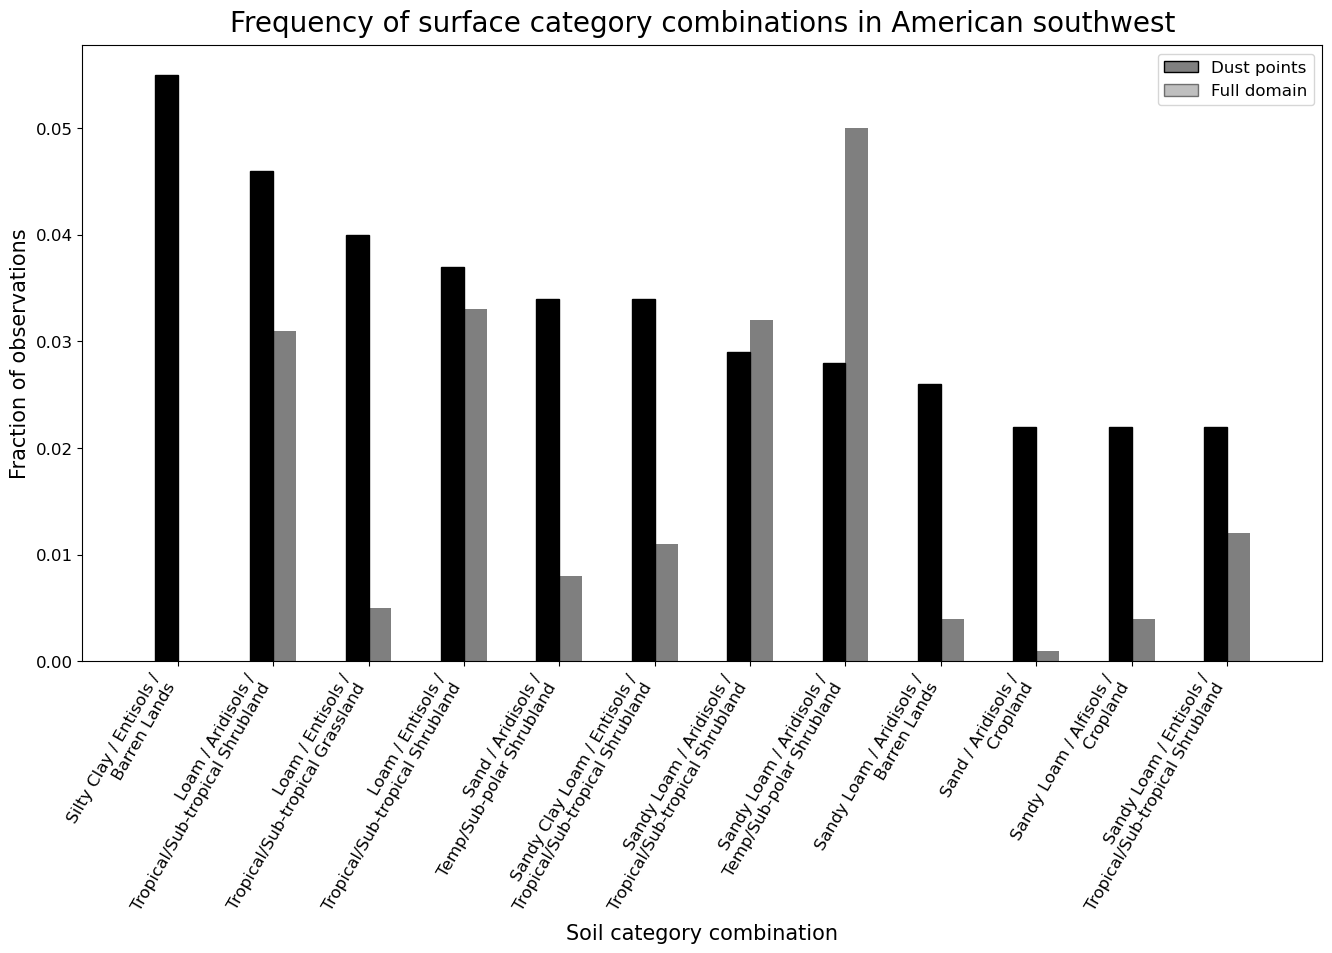

In [12]:
fig, ax = plt.subplots(figsize=(16, 8))

groups_selected = [39, 395, 365, 396, 299, 417,
                   422, 308, 24, 72, 79, 423] #--- IDs from combo_three dataframe
x = np.arange(len(groups_selected))
width = 0.24
x_labels = []

#--- Original method
for i, g in enumerate(groups_selected):
    ax.bar(x[i] - width/2, combo_three['dust_freq'][g], width=width, color="black", edgecolor="black", label="Dust points")
    ax.bar(x[i] + width/2, combo_three['control_freq'][g], width=width, color="black", alpha=0.5, edgecolor=None, label="Full domain")
    x_labels.append(f"{combo_three['texture'][g]} / {combo_three['soil_order'][g]} /\n {combo_three['usage'][g]}")

ax.set_xticks(x)
ax.tick_params(labelsize=12)
ax.set_xticklabels(x_labels, rotation=60, ha="right")
ax.set_ylabel("Fraction of observations", fontsize=15)
ax.set_xlim(-1, len(groups_selected))
ax.set_xlabel("Soil category combination", fontsize=15)
ax.set_title(f"Frequency of surface category combinations in American southwest", fontsize=20, pad=10)

legend_elements = [
    Patch(facecolor="gray", edgecolor="black", label="Dust points"),
    Patch(facecolor="gray", edgecolor="black", alpha=0.5, label="Full domain")
]
ax.legend(handles=legend_elements, fontsize=12)

plt.savefig(f"plots/6_combination_bar_chart.png",
            dpi=300, bbox_inches='tight')
plt.show()